# Distribuce počtu lezi na obratel

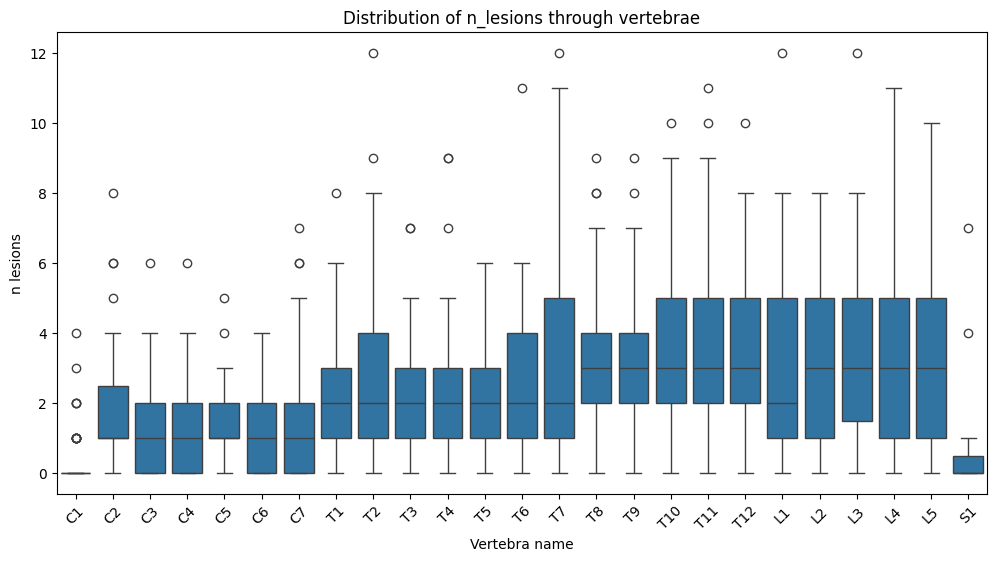

In [3]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

main_folder = r"E:\DATA_Myelomy"
all_data = []

for folder_name in os.listdir(main_folder):
    folder_path = os.path.join(main_folder, folder_name)
    csv_path = os.path.join(folder_path, "BMD_radiomics_vertebrae_features.csv")

    if os.path.isfile(csv_path):
        df = pd.read_csv(csv_path)
        df = df[['vertebra_name', 'n_lesions']]
        all_data.append(df)

full_df = pd.concat(all_data, ignore_index=True)

plt.figure(figsize=(12,6))
sns.boxplot(x='vertebra_name', y='n_lesions', data=full_df)
plt.title('Distribution of n_lesions through vertebrae')
plt.xlabel('Vertebra name')
plt.ylabel('n lesions')
plt.xticks(rotation=45)
plt.show()

# Relativní % obejmu lezi na obratel

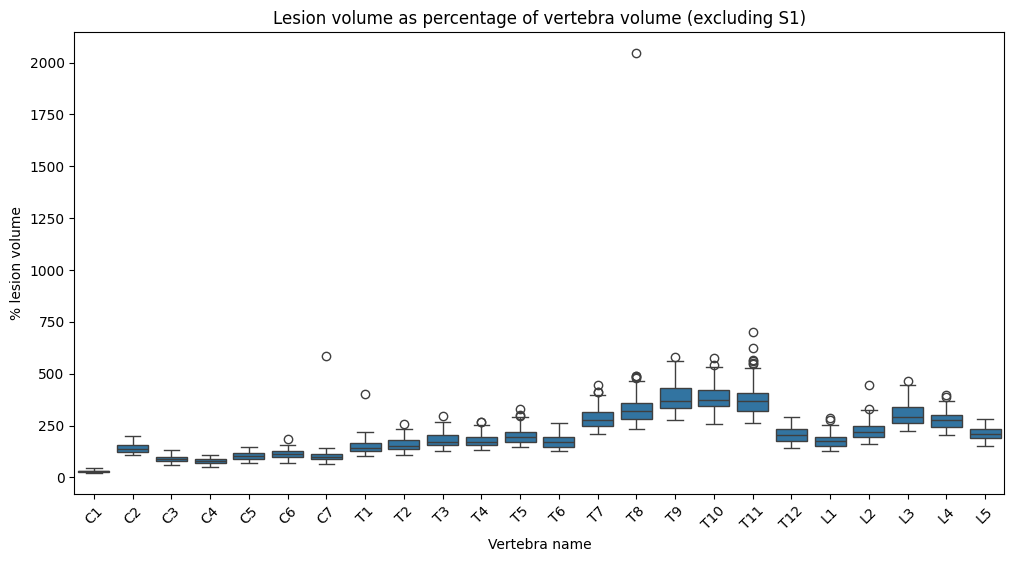

In [10]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

main_folder = r"E:\DATA_Myelomy"

vertebra_data = []
lesion_data = []

for folder_name in os.listdir(main_folder):
    folder_path = os.path.join(main_folder, folder_name)

    vertebra_csv = os.path.join(folder_path, "BMD_radiomics_vertebrae_features.csv")
    lesion_csv = os.path.join(folder_path, "BMD_radiomics_lesions_features.csv")

    if os.path.isfile(vertebra_csv):
        df_v = pd.read_csv(vertebra_csv)
        df_v = df_v[['vertebra_name', 'original_shape_VoxelVolume']]
        vertebra_data.append(df_v)

    if os.path.isfile(lesion_csv):
        df_l = pd.read_csv(lesion_csv)
        df_l = df_l[['vertebra_name', 'original_shape_VoxelVolume']]
        lesion_data.append(df_l)

# combine all vertebra and lesion data
if vertebra_data:
    df_vertebra = pd.concat(vertebra_data, ignore_index=True)
else:
    raise ValueError("No vertebra CSV files found!")

if lesion_data:
    df_lesion = pd.concat(lesion_data, ignore_index=True)
else:
    df_lesion = pd.DataFrame(columns=['vertebra_name', 'original_shape_VoxelVolume'])

# sum lesion volumes per vertebra
lesion_sum = df_lesion.groupby('vertebra_name')['original_shape_VoxelVolume'].sum().reset_index()
lesion_sum = lesion_sum.rename(columns={'original_shape_VoxelVolume': 'volume_lesion_sum'})

# merge with vertebra volume, fill missing lesion sums with 0
df = pd.merge(df_vertebra, lesion_sum, on='vertebra_name', how='left')
df['volume_lesion_sum'] = df['volume_lesion_sum'].fillna(0)  # vertebra without lesions get 0

# calculate lesion percentage
df['lesion_percent'] = df['volume_lesion_sum'] / df['original_shape_VoxelVolume'] * 100

# remove S1 vertebra
df = df[df['vertebra_name'] != 'S1']

# visualization
plt.figure(figsize=(12,6))
sns.boxplot(x='vertebra_name', y='lesion_percent', data=df)
plt.title('Lesion volume as percentage of vertebra volume (excluding S1)')
plt.xlabel('Vertebra name')
plt.ylabel('% lesion volume')
plt.xticks(rotation=45)
plt.show()

# % podiel objemu lezi -> štádium

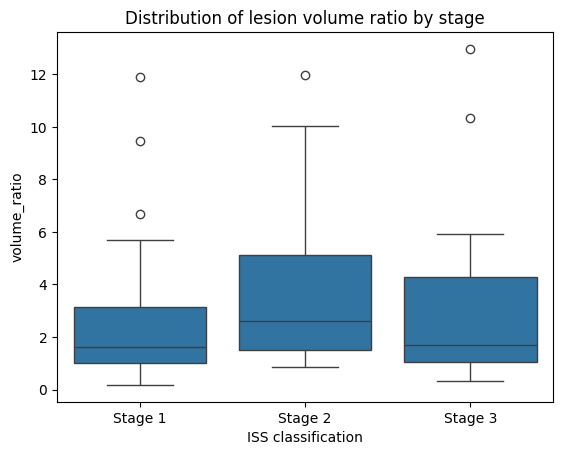

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_lesions = pd.read_csv(r"E:\CSV\merged\merged_CaSupp_25_radiomics_spine_lesions_features.csv").filter(items=["patient", "original_shape_VoxelVolume"])
df_vertebrae = pd.read_csv(r"E:\CSV\merged\merged_CaSupp_25_radiomics_spine_vertebrae_features.csv").filter(items=["patient", "original_shape_VoxelVolume"])

df_lesions = df_lesions.rename(columns={'original_shape_VoxelVolume': 'lesions_volume'})
df_vertebrae = df_vertebrae.rename(columns={'original_shape_VoxelVolume': 'vertebrae_volume'})

data = pd.merge(df_lesions, df_vertebrae[['patient', 'vertebrae_volume']], left_on='patient', right_on='patient')

pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv",encoding="cp1252")
df_final = pd.merge(data, clinical_df[['Patient ID', 'ISS classification']], left_on='patient', right_on='Patient ID')

df_final['volume_ratio'] = df_final['lesions_volume'] / df_final['vertebrae_volume'] * 100
sns.boxplot(data=df_final, x="ISS classification", y="volume_ratio")
plt.title('Distribution of lesion volume ratio by stage')
plt.show()

# % podiel objemu lezi -> b2 microglobulin

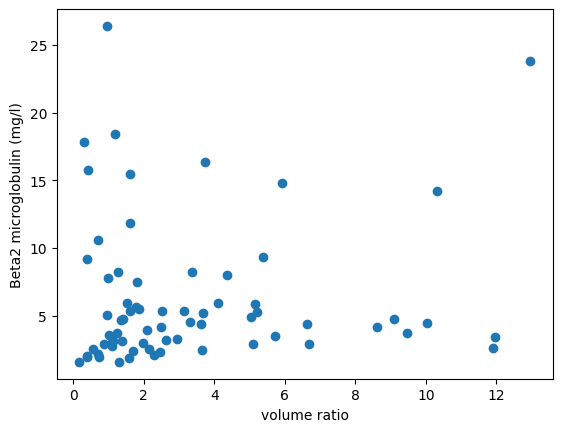

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

df_lesions = pd.read_csv(r"E:\CSV\merged\merged_CaSupp_25_radiomics_spine_lesions_features.csv").filter(items=["patient", "original_shape_VoxelVolume"])
df_vertebrae = pd.read_csv(r"E:\CSV\merged\merged_CaSupp_25_radiomics_spine_vertebrae_features.csv").filter(items=["patient", "original_shape_VoxelVolume"])

df_lesions = df_lesions.rename(columns={'original_shape_VoxelVolume': 'lesions_volume'})
df_vertebrae = df_vertebrae.rename(columns={'original_shape_VoxelVolume': 'vertebrae_volume'})

data = pd.merge(df_lesions, df_vertebrae[['patient', 'vertebrae_volume']], left_on='patient', right_on='patient')

pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv",encoding="cp1252")
df_final = pd.merge(data, clinical_df[['Patient ID', 'Beta2 microglobulin (mg/l)']], left_on='patient', right_on='Patient ID')

df_final['volume_ratio'] = df_final['lesions_volume'] / df_final['vertebrae_volume'] * 100
plt.scatter(df_final['volume_ratio'], df_final['Beta2 microglobulin (mg/l)'])
plt.xlabel('volume ratio')
plt.ylabel('Beta2 microglobulin (mg/l)')
plt.show()